# Salary Analysis: How well do jobs and skills pay for Data Analysts?

## Import Libraries and Data

In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Loading Dataset
df = pd.read_csv(r'C:\Users\ARJUN\Python_projects\Python_Course\data_jobs.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

## Filter for the US

In [2]:
df_US = df[df['job_country'] == 'United States'].dropna(subset = ['salary_year_avg']).copy()

## Extract the top 6 job titles

In [3]:
job_titles = df_US['job_title_short'].value_counts()[0:6].index.to_list()
job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

## Plot Salary Distributions

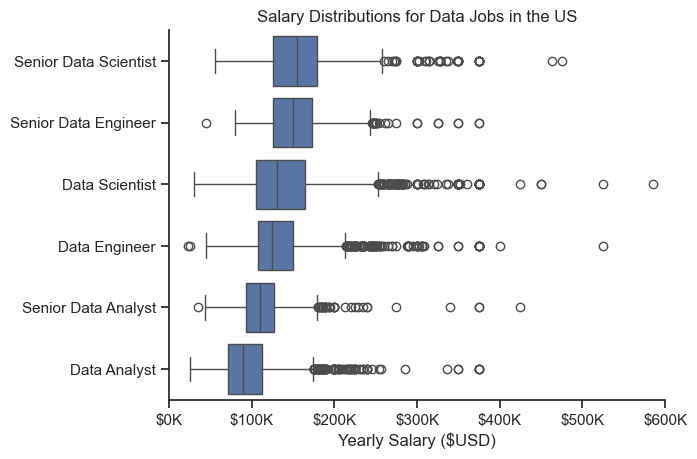

In [4]:
# df_plot = [df_US['salary_year_avg'][df_US['job_title_short'] == job_title] for job_title in job_titles]
# plt.boxplot(df_plot, vert = False, labels = job_titles)

sns.set_theme(style = 'ticks')

(
    sns.boxplot(
    data = df_US[df_US['job_title_short'].isin(job_titles)], x = 'salary_year_avg', y = 'job_title_short', 
    
    order = df_US[df_US['job_title_short'].isin(job_titles)].groupby('job_title_short')['salary_year_avg'].agg('median')
    .sort_values(ascending = False).index)
)
sns.despine()
plt.title('Salary Distributions for Data Jobs in the US')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()

## Median Salary vs Skill for Data Analysts in the US

## Filter for US Data Analysts

In [5]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].dropna(subset = ['salary_year_avg']).copy()

## Explode the skills column

In [6]:
df_DA_US_exploded = df_DA_US.explode('job_skills')

## Top Paid Skills

In [7]:
df_top_paid = (
    df_DA_US_exploded
    .groupby('job_skills')['salary_year_avg']
    .agg(['count','median'])
    .sort_values(by = 'median', ascending = False)
    .rename(columns = {'count':'Skill_Cnt', 'median':'Median_Salary'})
    .head(10)
    )
df_top_paid

,Skill_Cnt,Median_Salary
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


## Top Demanded Skills

In [8]:
df_top_demanded = (
    df_DA_US_exploded
    .pivot_table(index = 'job_skills', values = 'salary_year_avg', aggfunc = ['count','median'])
    .sort_values(by = ('count','salary_year_avg'), ascending = False)
    .head(10)
    .sort_values(by = ('median','salary_year_avg'), ascending = False)
    )
df_top_demanded.columns = ['Skill_Cnt', 'Median_Salary']
df_top_demanded

,Skill_Cnt,Median_Salary
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


## Plot Top Paid and Top Demanded Skills

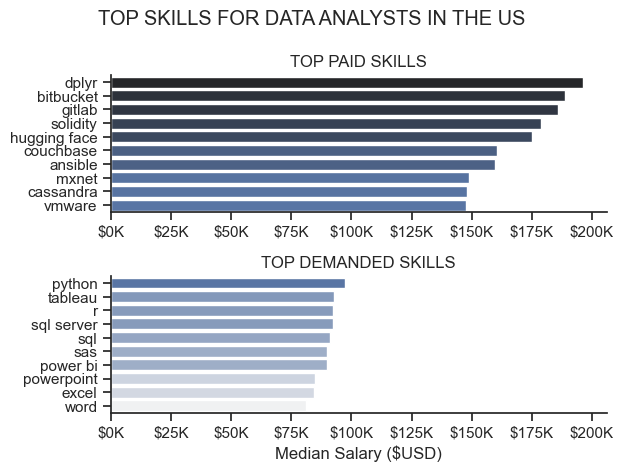

In [9]:
fig, ax = plt.subplots(2,1)

sns.set_theme(style = 'ticks')

# df_top_paid.plot(kind = 'barh', y = 'Median_Salary', ax = ax[0])
# ax[0].invert_yaxis()
sns.barplot(data = df_top_paid, x = 'Median_Salary', y = df_top_paid.index, ax = ax[0], hue = 'Median_Salary', palette = 'dark:b_r')
ax[0].set_title('TOP PAID SKILLS')
ax[0].legend().set_visible(False)
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# df_top_demanded.plot(kind = 'barh', y = 'Median_Salary', ax = ax[1])
# ax[1].invert_yaxis()
sns.barplot(data = df_top_demanded, x = 'Median_Salary', y = df_top_demanded.index, ax = ax[1], hue = 'Median_Salary', palette = 'light:b')
ax[1].set_title('TOP DEMANDED SKILLS')
ax[1].legend().remove()
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())

sns.despine()
fig.suptitle('TOP SKILLS FOR DATA ANALYSTS IN THE US')
fig.tight_layout(h_pad = 1.0)
plt.show()